In [71]:
import numpy as np
import scipy.integrate
import scipy as sp
import matplotlib.pyplot as plt
from numpy import sqrt
from numpy.linalg import norm
import scipy.io as scio
from scipy import interpolate
import scipy.special as special
import math
from numpy import tanh, cosh, sqrt, cos, sin, exp, log, pi
from scipy.integrate import quad, quad_vec
from scipy.optimize import fsolve, bisect, dual_annealing, minimize_scalar, differential_evolution

In [72]:
"""
Numerical helpers for computing the replica
equations, specialised to the exponent gamma = 0.5.

The main objects computed here are:
  - m(lambda)    : 1 - mmseS(lambda), where mmseS(x) is the MMSE of the
                   symmetric Wishart matrix denoising problem
                       Y(x) = sqrt(x) * S0 + Z,
                   with signal S0 = W0^T diag(v0) W0 / sqrt(k*d), Z a GOE
                   matrix, as defined in Sec. II (just before Result 1).
                   Via the I-MMSE relation  4 * d/dx iota(x) = mmseS(x),
                   one has  mmseS(x) = 1 - m(x).
                   m(lambda) enters the moment-matching condition (B39):
                       mmseS(tau) = 1 - E_v[v^2 Q(v)^2]
                   i.e.  m(tau) = E_v[v^2 Q(v)^2].

  - M(lambda)    : the antiderivative  integral_0^lambda m(t) dt,
                   precomputed offline so that iota can be evaluated cheaply
                   as  iota(lambda) = (lambda - M(lambda)) / 4.

  - iota(lambda) : the limiting mutual information (per d^2) of the symmetric
                   matrix denoising problem defined in Sec. II,
                       iota(x) = lim_{d->inf} (1/d^2) I(Y(x); S~0).
                   It is related to the HCIZ spherical integral and is computed
                   via the I-MMSE identity  iota(x) = (1/4) int_0^x mmseS(t) dt,
                   which gives the closed form  iota(lambda) = (lambda - M(lambda)) / 4.
                   The two iota(.) terms appearing in the RS free-energy f^(1)_RS
                   (eq. (15)) originate from this spherical integration step.

  - psi_w        : posterior-mean function  E_z[tanh(sqrt(l)*z + l)],  z ~ N(0,1),
                   equal to  E_{w^0,xi}[w^0 <w>_{Q-hat}]  entering the saddle-point
                   equations (B41) for the overlap Q(v).
  - psi_fe       : scalar-channel free-entropy  psi_{P_W}(x) defined in Sec. II,
                   evaluated as  E_z[log cosh(sqrt(g)*z + g)] - g/2,  z ~ N(0,1).

Both psi functions admit a closed-form when the inner weights are Gaussian; 
for all other readouts we fall back to Gauss-Hermite quadrature.

The m and M values are loaded from CSV files (precomputed offline) and
interpolated at runtime with cubic splines, avoiding expensive recomputation.

Supported readout distributions (set via the `readouts` variable):
  'Read_gauss'   – Gaussian readout weights
  'Read_rad'     – Rademacher (+/-1) readout weights
  'Read_ones'    – all-ones readout weights
  'Read_unif'    – uniform readout weights
  'Read_4point'  – 4-point discrete readout weights
"""

import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq


# ---------------------------------------------------------------------------
# Aspect ratio (fixed at 0.5 throughout; functions are specialised for it)
# ---------------------------------------------------------------------------
GAMMA: float = 0.5


# ---------------------------------------------------------------------------
# Gauss-Hermite quadrature setup  (order 40, computed once at import time)
#
# Gauss-Hermite integrates  int f(x) e^{-x^2} dx  with nodes x_i and
# weights w_i.  We transform to standard-normal expectations:
#   E_z[f(z)] = (1/sqrt(pi)) * sum_i w_i * f(sqrt(2) * x_i),   z ~ N(0,1).
# ---------------------------------------------------------------------------
_GH_ORDER = 40
_GH_x, _GH_w = hermgauss(_GH_ORDER)          # nodes & weights for e^{-x^2}
_GH_scale    = 1.0 / np.sqrt(np.pi)           # normalisation constant
_GH_z        = np.sqrt(2.0) * _GH_x           # standard-normal nodes,  shape (N,)
_GH_w_scaled = _GH_w * _GH_scale              # normalised weights,      shape (N,)


def _gh_expectation_from_vals(vals: np.ndarray) -> np.ndarray:
    """
    Compute a Gaussian expectation from pre-evaluated function values.

    Given a matrix `vals` of shape (N, ...) where the first axis aligns with
    the GH nodes, returns the weighted sum over that axis, i.e.
        sum_i w_i * vals[i, ...]
    which approximates  E_z[f(z)]  for z ~ N(0,1).
    """
    return np.tensordot(_GH_w_scaled, vals, axes=(0, 0))


# ---------------------------------------------------------------------------
# Prior distribution over the inner weights  (controls psi_w / psi_fe)
#
# 'gauss' : Gaussian prior  N(0,1) on the inner weights.
#           Enables closed-form expressions for psi_w and psi_fe,
#           making evaluation significantly faster.
#
# 'rad'   : Rademacher prior  (+1 / -1 with equal probability).
#           Falls back to Gauss-Hermite quadrature for psi_w and psi_fe.
#
# To switch prior, comment out the active line and uncomment the other.
# ---------------------------------------------------------------------------
#opt = 'rad'
opt = 'gauss'

_VALID_OPTS = ('gauss', 'rad')
if opt not in _VALID_OPTS:
    raise ValueError(f"Unknown inner-weight prior '{opt}'. Choose from: {_VALID_OPTS}")

# ---------------------------------------------------------------------------
# Readout selection and CSV loading
#
# Each CSV file holds precomputed (lambda, m, M) triplets for a specific
# readout distribution, where:
#   Row 0  = lambda grid  (SNR values for the matrix denoising problem)
#   Row 1  = m(lambda) = 1 - mmseS(lambda), with mmseS the MMSE of the
#            symmetric Wishart matrix denoising problem (see Sec. II)
#   Row 2  = M(lambda) = integral_0^lambda m(t) dt  (antiderivative of m),
#            used to evaluate iota(lambda) = (lambda - M(lambda)) / 4.
# ---------------------------------------------------------------------------
readouts = 'Read_ones'   # <-- change here to switch readout type

_CSV_MAP = {
    'Read_gauss' : 'gauss.csv',
    'Read_rad'   : 'rad.csv',
    'Read_ones'  : 'ones.csv',
    'Read_unif'  : 'unif.csv',
    'Read_4point': '4point.csv',
}

if readouts not in _CSV_MAP:
    raise ValueError(
        f"Unknown readout '{readouts}'. Choose from: {list(_CSV_MAP.keys())}"
    )

data = np.loadtxt(_CSV_MAP[readouts], delimiter=',')

# Parse the three rows of the CSV
lambdas  = data[0, :]   # SNR grid for the matrix denoising problem
m_values = data[1, :]   # m(lambda) = 1 - mmseS(lambda)
M_values = data[2, :]   # M(lambda) = integral_0^lambda m(t) dt

# Build cubic splines for fast evaluation at arbitrary lambda
m_spline = CubicSpline(lambdas, m_values, extrapolate=True)
M_spline = CubicSpline(lambdas, M_values, extrapolate=True)


# ---------------------------------------------------------------------------
# Spline-based evaluations of m and iota
# ---------------------------------------------------------------------------

def m_05(lam: np.ndarray | float,
         m_spline_local: CubicSpline | None = None) -> np.ndarray | float:
    """
    Evaluate  m(lambda) = 1 - mmseS(lambda)  via a precomputed cubic spline,
    where mmseS(x) is the MMSE of the symmetric Wishart matrix denoising problem

        Y(x) = sqrt(x) * S0 + Z,

    with signal  S0 = W0^T diag(v0) W0 / sqrt(k*d),  noise Z a GOE matrix,
    and aspect ratio gamma = k/d = 0.5  (see Sec. II, just before Result 1).

    m(lambda) enters the moment-matching condition (B39):
        mmseS(tau) = 1 - E_v[v^2 Q(v)^2]   <=>   m(tau) = E_v[v^2 Q(v)^2],
    which determines the tilt parameter tau(Q) linking the matrix-model and
    mean-field parts of the RS free energy f^(1)_RS (eq. (15)).

    Parameters
    ----------
    lam            : scalar or array of SNR values.
    m_spline_local : optional override spline (useful in unit tests or
                     when running multiple readout types simultaneously).

    Returns
    -------
    Scalar float if `lam` is scalar, numpy array otherwise.
    """
    spline  = m_spline_local if m_spline_local is not None else m_spline
    lam_arr = np.asarray(lam)
    out     = spline(lam_arr)
    return float(out) if out.shape == () else np.asarray(out)


def iota_05(lam: np.ndarray | float,
            M_spline_local: CubicSpline | None = None) -> np.ndarray | float:
    """
    Evaluate  iota(lambda) = (lambda - M(lambda)) / 4,

    where  iota(x) = lim_{d->inf} (1/d^2) I(Y(x); S0)  is the limiting
    mutual information per d^2 of the symmetric matrix denoising problem

        Y(x) = sqrt(x) * S0 + Z

    defined in Sec. II (just before Result 1).  It is related to the
    HCIZ spherical integral and enters the RS free energy f^(1)_RS (eq. (15))
    through the two terms  iota(tau(Q))  and  iota(R-hat_2 + tau(Q)).

    The closed form follows from the I-MMSE relation (eq. (B34)),
        4 * d/dx iota(x) = mmseS(x) = 1 - m(x),
    by integration:
        iota(lambda) = (1/4) * integral_0^lambda mmseS(t) dt
                     = (1/4) * integral_0^lambda (1 - m(t)) dt
                     = (lambda - M(lambda)) / 4,
    where  M(lambda) = integral_0^lambda m(t) dt  is precomputed in the CSV.

    Parameters
    ----------
    lam            : scalar or array of SNR values.
    M_spline_local : optional override spline (same rationale as m_05).

    Returns
    -------
    Scalar float if `lam` is scalar, numpy array otherwise.
    """
    spline  = M_spline_local if M_spline_local is not None else M_spline
    lam_arr = np.asarray(lam)
    Mvals   = spline(lam_arr)
    out     = (lam_arr - Mvals) / 4.0
    return float(out) if out.shape == () else np.asarray(out)


# ---------------------------------------------------------------------------
# Channel functions: psi_w (posterior mean) and psi_fe (free energy)
# ---------------------------------------------------------------------------

def psi_w_arr(l_arr: np.ndarray | float, opt: str = 'gauss') -> np.ndarray:
    """
    Compute the posterior-mean channel function entering the saddle-point
    equations (B41) for the overlap Q(v):

        psi_w(l) = E_{w^0, xi}[ w^0 <w>_l ]
                 = E_z[ tanh(sqrt(l) * z + l) ],   z ~ N(0,1),

    where <w>_l is the posterior mean of w under the scalar Gaussian channel
    y = sqrt(l) w^0 + xi with prior P_W on w^0.

    For a Gaussian prior over the inner weights this simplifies to the
    closed form  l / (1 + l).  A Rademacher prior requires Gauss-Hermite
    quadrature.

    Parameters
    ----------
    l_arr : scalar or array of effective-SNR values.
    opt   : prior over the inner weights — 'gauss' or 'rad'.

    Returns
    -------
    Array of the same shape as `l_arr`.
    """
    if opt not in _VALID_OPTS:
        raise ValueError(
            f"Unknown inner-weight prior '{opt}'. Choose from: {_VALID_OPTS}"
        )

    l = np.asarray(l_arr)

    if opt == 'gauss':
        # Closed-form: posterior mean under a Gaussian prior on the inner weights
        return l / (1.0 + l)

    # Rademacher prior: posterior mean via numerical GH quadrature.
    # Build tanh( sqrt(l) * z_i + l ) for all nodes z_i and all l values.
    # sqrt clipped to 0 to guard against tiny negative l from numerical noise.
    l_flat  = l.ravel()
    sqrt_l  = np.sqrt(np.maximum(0.0, l_flat))                      # (L,)
    arg     = _GH_z[:, None] * sqrt_l[None, :] + l_flat[None, :]    # (N, L)
    vals    = np.tanh(arg)                                           # (N, L)
    exps    = _gh_expectation_from_vals(vals)                        # (L,)
    return exps.reshape(l.shape)


def psi_free_energy_arr(g_arr: np.ndarray | float, opt: str = 'gauss') -> np.ndarray:
    """
    Compute the scalar-channel free-entropy psi_{P_W}(x) defined in Sec. II:

        psi_{P_W}(x) = E_{w^0, xi} ln E_w exp(-x/2 w^2 + x w^0 w + sqrt(x) xi w)

    evaluated as

        psi_fe(g) = E_z[ log cosh(sqrt(g) * z + g) ] - g/2,   z ~ N(0,1).

    This is the free entropy of the scalar Gaussian observation channel
    y_G = sqrt(x) w^0 + xi with prior P_W on w^0, where x plays the role
    of signal-to-noise ratio. It appears in the RS free energy f^(1)_RS
    (eq. (15)) through the psi_{P_W}(Q-hat(v)) terms governing the
    specialisation transition(s).

    For a Gaussian prior over the inner weights this simplifies to
    g/2 - log(1+g)/2.  A Rademacher prior requires Gauss-Hermite quadrature.

    Parameters
    ----------
    g_arr : scalar or array of effective-SNR values.
    opt   : prior over the inner weights — 'gauss' or 'rad'.

    Returns
    -------
    Array of the same shape as `g_arr`.
    """
    if opt not in _VALID_OPTS:
        raise ValueError(
            f"Unknown inner-weight prior '{opt}'. Choose from: {_VALID_OPTS}"
        )

    g = np.asarray(g_arr)

    if opt == 'gauss':
        # Closed-form: free energy under a Gaussian prior on the inner weights
        return 0.5 * g - 0.5 * np.log(1.0 + g)

    # Rademacher prior: free energy via numerical GH quadrature.
    g_flat  = g.ravel()
    sqrt_g  = np.sqrt(np.maximum(0.0, g_flat))                      # (L,)
    arg     = _GH_z[:, None] * sqrt_g[None, :] + g_flat[None, :]    # (N, L)
    vals    = np.log(np.cosh(arg))                                   # (N, L)
    exps    = _gh_expectation_from_vals(vals)                        # (L,)
    out     = -0.5 * g_flat + exps
    return out.reshape(g.shape)


# ---------------------------------------------------------------------------
# Expectations over the discrete weight distribution P_v
# ---------------------------------------------------------------------------

def EE_v(arr: np.ndarray, P_v: np.ndarray) -> float:
    """
    Compute E_{v ~ P_v}[ arr(v) ] = sum_k P_v[k] * arr[k].

    Parameters
    ----------
    arr : values evaluated at each support point of P_v.
    P_v : probability vector over the support of v.
    """
    return float(np.tensordot(np.asarray(P_v), arr, axes=(0, 0)))


def EE_v2_g(q_W: np.ndarray, v: np.ndarray, P_v: np.ndarray,
            g: callable) -> float:
    """
    Compute E_{v ~ P_v}[ v^2 * g(q_W(v)) ] = sum_k P_v[k] * v[k]^2 * g(q_W[k]).

    Parameters
    ----------
    q_W : array of overlap values, one per support point of P_v.
    v   : support points of the weight distribution.
    P_v : probability weights.
    g   : callable applied elementwise to q_W.
    """
    return float(np.dot(P_v, (v ** 2) * g(np.asarray(q_W))))


def EE_v2_qW2(q_W: np.ndarray, v: np.ndarray, P_v: np.ndarray) -> float:
    """
    Compute E_{v ~ P_v}[ v^2 * q_W(v)^2 ] = sum_k P_v[k] * v[k]^2 * q_W[k]^2.

    Parameters
    ----------
    q_W : array of overlap values, one per support point of P_v.
    v   : support points of the weight distribution.
    P_v : probability weights.
    """
    return float(np.dot(P_v, (v ** 2) * (np.asarray(q_W) ** 2)))

# ---------------------------
# Vectorized wrappers for m_05 and iota_05 used by inverse/derivative
# ---------------------------
def _m_05_vec(l):
    """
    Robust vectorized wrapper for m_05 that returns an array of same shape as input l.
    Tries direct call; falls back to np.vectorize if needed.
    """
    l = np.asarray(l)
    try:
        res = m_05(l)   # m_05 may accept arrays directly (fast)
        return np.asarray(res)
    except Exception:
        vec = np.vectorize(lambda x: m_05(x))
        return np.asarray(vec(l))


def _iota_05_vec(l):
    """
    Robust wrapper for iota_05, analogous to _m_05_vec.
    """
    l = np.asarray(l)
    try:
        res = iota_05(l)
        return np.asarray(res)
    except Exception:
        vec = np.vectorize(lambda x: iota_05(x))
        return np.asarray(vec(l))    


# ---------------------------------------------------------------------------
# Inverse of m: find lambda such that m(lambda) = E_v[v^2 * Q(v)^2]
#
# This implements the moment-matching condition (B39) of the paper:
#     mmseS(tau) = 1 - E_v[v^2 Q(v)^2]   <=>   m(tau) = E_v[v^2 Q(v)^2],
# which determines the tilt parameter tau(Q) that links the matrix-denoising
# part (iota terms) to the specialisation order parameters Q(v) in f^(1)_RS.
# ---------------------------------------------------------------------------

def m_s_inv_05_fast(q_W: np.ndarray, gamma: float,
                    v: np.ndarray, P_v: np.ndarray,
                    bracket_hi: float = 1.0,
                    max_hi: float = 1e6) -> float:
    """
    Solve the moment-matching condition (B39) for the tilt parameter tau:

        m(tau) = E_{v ~ P_v}[ v^2 * q_W(v)^2 ],

    i.e. find  tau >= 0  such that  1 - mmseS(tau) = E_v[v^2 Q(v)^2].
    This is the inverse of  m(lambda) = 1 - mmseS(lambda)  evaluated at
    the right-hand side  E_v[v^2 q_W^2].

    Uses Brent's method on [0, lambda_hi], doubling lambda_hi until
    the root is bracketed.  Falls back gracefully if no bracket is found.

    Parameters
    ----------
    q_W        : overlap array Q(v), shape matching the support of P_v.
    gamma      : channel aspect ratio k/d (currently unused; kept for
                 consistency with the general-gamma version of this function).
    v          : support points of the weight distribution.
    P_v        : probability weights.
    bracket_hi : initial upper bound for the Brent bracket.
    max_hi     : maximum value lambda_hi is allowed to reach.

    Returns
    -------
    The root tau* as a float (0.0 if the target is already matched at 0).
    """
    target = EE_v2_qW2(q_W, v, P_v)   # right-hand side: E[v^2 * q_W^2]

    def residual(l: float) -> float:
        """m(l) - target, evaluated as a scalar."""
        return float(m_spline(np.array([l]))[0]) - target

    f0 = residual(0.0)
    if abs(f0) < 1e-12:
        return 0.0   # target is already matched at lambda = 0

    # Try the initial bracket [0, bracket_hi]
    lo, hi = 0.0, float(bracket_hi)
    fhi = residual(hi)

    # If initial bracket already straddles the root, solve immediately
    if f0 * fhi <= 0:
        try:
            return float(brentq(residual, lo, hi, xtol=1e-12, maxiter=200))
        except Exception:
            pass   # rare edge case; fall through to doubling

    # Bracket doubling: keep widening until signs differ or limit reached
    while f0 * fhi > 0 and hi < max_hi:
        hi  *= 2.0
        fhi  = residual(hi)

    if f0 * fhi > 0:
        # Could not bracket: return the endpoint with the smaller residual
        return 0.0 if abs(f0) <= abs(fhi) else float(hi)

    return float(brentq(residual, lo, hi, xtol=1e-12, maxiter=200))


# ---------------------------------------------------------------------------
# Derivative of mmseS via finite differences on m = 1 - mmseS
# ---------------------------------------------------------------------------

def derivative_mmse_05_fast(l, h=1e-6):
    """
    Compute  d/dl mmseS(l) = d/dl [1 - m(l)]  using central finite differences.

    Since  m(l) = 1 - mmseS(l),  the derivative of mmseS is:
        d/dl mmseS(l) = -m'(l) = ( (1 - m(l+h)) - (1 - m(l-h)) ) / (2h).

    This quantity is proportional to  iota''(l)  via the I-MMSE relation
    4 * iota'(l) = mmseS(l)  (eq. (B34)).

    Parameters
    ----------
    l : SNR value at which to evaluate the derivative.
    h : finite-difference step size.

    Returns
    -------
    The derivative  d mmseS / dl  evaluated at l.
    """
    l = float(l)
    m_plus = float(_m_05_vec(np.array([l + h]))[0])
    m_minus = float(_m_05_vec(np.array([l - h]))[0])
    # d/dl mmseS(l) = -d/dl m(l) = ( (1 - m_plus) - (1 - m_minus) ) / (2h)
    return ( (1.0 - m_plus) - (1.0 - m_minus) ) / (2.0 * h)

In [ ]:
def Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2,
                           max_iter=100, tol=1e-6):
    """
    Compute the diagonal K_d and off-diagonal K* of the limiting covariance
    matrix K* of the post-activations (eq. (10)/(16)), given the specialisation
    overlaps Q(v) = q_W.

    From eq. (13) of the paper the two covariance entries read
        K_d  = mu_1^2 + mu_2^2 * R_d / 2 + g(1),          (variance,    = r_K)
        K*   = mu_1^2 + mu_2^2 * R_2 / 2 + E_v[v^2 g(Q(v))], (off-diag, = q_K)
    where R_d = 1 + gamma * v-bar^2  (= rho_2) is fixed by the Nishimori
    identity (A13), while R_2 (the quadratic overlap, = q_2) is determined
    self-consistently by the third saddle-point equation in (B43):
        R_2 = R_d - mmseS(tau + R-hat_2)
            = (rho_2 - 1) + m(tau + R-hat_2),     m = 1 - mmseS,
    with the conjugate R-hat_2 (= r_2) given by the fourth equation of (B43):
        R-hat_2 = alpha * mu_2^2 / (Delta + K_d - K*)
                = alpha * mu_2^2 / (delta + r_K - q_K),
    and the tilt tau (= tilde_q) from the moment-matching condition (B39):
        tau = mmseS^{-1}(1 - E_v[v^2 Q(v)^2])  <=>  m(tau) = E_v[v^2 q_W^2].

    The iteration alternates between updating R-hat_2, tau, R_2 and then K*
    until K* converges, with K_d remaining constant throughout.

    Parameters
    ----------
    q_W    : array of shape (V,), specialisation overlaps Q(v) (fixed input).
    v      : support points of the readout distribution P_v.
    P_v    : probability weights of P_v.
    g      : function g(x) = sum_{ell>=3} mu_ell^2 / ell! * x^ell  (eq. B6).
    coeff  : Hermite coefficients [mu_0, mu_1, mu_2, ...] of the activation.
    alpha  : sampling ratio n/d^2.
    gamma  : aspect ratio k/d = 0.5.
    delta  : label-noise variance Delta of the Gaussian output channel.
    rho_2  : R_d = 1 + gamma * v-bar^2 (diagonal second moment, Nishimori).
    max_iter, tol : iteration budget and convergence threshold.

    Returns
    -------
    r_K : K_d  — variance of the post-activation Gaussian (eq. 13).
    q_K : K*   — off-diagonal covariance between two post-activation replicas
                 (eq. 16); gives the Bayes error as  epsilon* = K_d - K*  (eq. 20).
    """
    mu1_sq = coeff[1]**2
    mu2_sq = coeff[2]**2

    # K_d = mu_1^2 + mu_2^2 * R_d / 2 + g(1)  (eq. 13, Nishimori-fixed diagonal)
    r_K = coeff[1]**2 + rho_2 * coeff[2]**2 / 2.0 + g(1.0)

    # initialize q_K_new (K*) at the midpoint r_K/2 before the first iteration
    q_K_new = r_K / 2.0

    for _ in range(max_iter):
        q_K_old = q_K_new

        # R-hat_2 from the 4th saddle-point eq. (B43) for the Gaussian channel:
        #   R-hat_2 = alpha * mu_2^2 / (Delta + K_d - K*)
        r_2 = alpha * (1.0 / (delta + r_K - q_K_old)) * (coeff[2]**2)

        # tau = mmseS^{-1}(1 - E_v[v^2 Q(v)^2])  from moment-matching (B39):
        #   m(tau) = E_v[v^2 q_W^2],  m = 1 - mmseS
        tilde_q = m_s_inv_05_fast(q_W, gamma, v, P_v)

        # R_2 from the 3rd saddle-point eq. (B43):
        #   R_2 = R_d - mmseS(tau + R-hat_2) = (rho_2 - 1) + m(tau + R-hat_2)
        q_2 = float(_m_05_vec(np.array([tilde_q + r_2]))[0]) + (rho_2 - 1.0)

        # K* = mu_1^2 + mu_2^2 * R_2 / 2 + E_v[v^2 g(Q(v))]  (eq. 13)
        q_K_new = coeff[1]**2 + (coeff[2]**2) / 2.0 * q_2 + EE_v2_g(q_W, v, P_v, g)

        if abs(q_K_new - q_K_old) < tol:
            break

    return r_K, q_K_new


def mmse_qW_q2_full_NSB_iter_05_fast(q_W_init, v, P_v, g, g_prime,
                                     coeff, alpha, gamma, delta, rho_2,
                                     max_iter=1000, tol=1e-6, dump=0.2, univ=False):
    """
    Fixed-point solver for the full RS saddle-point equations (B41)/(B43),
    iterating jointly over the specialisation overlaps Q(v) and the quadratic
    overlap R_2 until convergence.

    At each iteration the update reads (eqs. B41/B43):

      1.  Compute K_d (r_K) and K* (q_K) via Kappa_full_NSB_05_fast given
          the current Q(v).

      2.  R-hat_2 = alpha * mu_2^2 / (Delta + K_d - K*)   [4th eq. of (B43)]

      3.  tau = m^{-1}(E_v[v^2 Q(v)^2])                   [moment-matching (B39)]

      4.  R_2 = (rho_2 - 1) + m(tau + R-hat_2)            [3rd eq. of (B43)]

      5.  Q-hat(v) = r_W(v), the conjugate overlap, assembled from
          the partial derivative of f^(1)_RS w.r.t. Q(v)  [2nd eq. of (B43)]:
              Q-hat(v) = (1/(2*gamma)) * (R_2 - gamma*v-bar^2 - E_v[v^2 Q^2])
                         * (-2 v^2 Q(v) / mmseS'(tau))
                       + (alpha/gamma) * v^2 * g'(Q(v)) / (Delta + K_d - K*)
          where mmseS'(tau) = d mmseS/dl |_{tau}  (via finite differences on m).

      6.  Q(v) <- psi_w(Q-hat(v)) = E_{w^0,xi}[w^0 <w>_{Q-hat(v)}]
                                                             [1st eq. of (B41)]
          damped by the factor `dump` for stability.

    Setting `univ=True` forces Q(v) = 0 at every step, which tracks the
    universal (non-specialised) branch of the RS equations, however the
    same branch can be obtained by initialising q_W_init=0

    Parameters
    ----------
    q_W_init : initial array of shape (V,) for Q(v).
    v, P_v   : support and weights of P_v.
    g        : function g(x)  (eq. B6).
    g_prime  : derivative g'(x).
    coeff    : Hermite coefficients [mu_0, mu_1, mu_2, ...].
    alpha    : sampling ratio n/d^2.
    gamma    : aspect ratio k/d = 0.5.
    delta    : label-noise variance Delta.
    rho_2    : R_d = 1 + gamma * v-bar^2.
    max_iter : maximum number of outer iterations.
    tol      : convergence threshold on |K*_{new} - K*_{old}|.
    dump     : damping coefficient for Q(v) update (0 < dump <= 1).
    univ     : if True, pin Q(v)=0 to track the universal branch.

    Returns
    -------
    mmse  : Bayes-optimal mean-square generalisation error (with Delta removed),
            epsilon* = K_d - K*  (eq. 20).
    q_W   : equilibrium specialisation overlaps Q*(v)  (RS order parameters).
    q_2   : equilibrium quadratic overlap R_2*          (RS order parameter).
    """
    q_W = np.array(q_W_init, dtype=float).copy()  # shape (V,)
    V = v.shape[0]

    r_W = np.empty_like(q_W)

    # Initial evaluation of K_d and K* at the starting overlaps
    r_K, q_K = Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2,
                                         max_iter=200, tol=1e-6)

    for it in range(max_iter):
        # ------------------------------------------------------------------ #
        # Step 1: R-hat_2 from 4th saddle-point eq. (B43)                   #
        # ------------------------------------------------------------------ #
        r_2 = alpha * (1.0 / (delta + r_K - q_K)) * (coeff[2]**2)

        # ------------------------------------------------------------------ #
        # Step 2: tau from moment-matching condition (B39)                    #
        # ------------------------------------------------------------------ #
        tilde_q = m_s_inv_05_fast(q_W, gamma, v, P_v)

        # ------------------------------------------------------------------ #
        # Step 3: R_2 from 3rd saddle-point eq. (B43)                        #
        # ------------------------------------------------------------------ #
        q_2 = float(_m_05_vec(np.array([tilde_q + r_2]))[0]) + (rho_2 - 1.0)

        # ------------------------------------------------------------------ #
        # Step 4: Q-hat(v) = r_W(v) from 2nd saddle-point eq. (B43)         #
        # Assembles the two contributions:                                    #
        #   term1: matrix-denoising part, proportional to                     #
        #          (R_2 - gamma*v-bar^2 - E_v[v^2 Q^2]) * (-2v^2 Q(v))      #
        #          / mmseS'(tau),  coming from d/d_{Q(v)} [iota terms]       #
        #   term2: scalar-channel (specialisation) part, proportional to      #
        #          v^2 g'(Q(v)) / (Delta + K_d - K*),                        #
        #          coming from d/d_{Q(v)} [psi_{P_W} terms]                  #
        # ------------------------------------------------------------------ #
        E_v2_qW2_val = EE_v2_qW2(q_W, v, P_v)          # E_v[v^2 Q(v)^2], scalar
        denom_common = 1.0 + r_2 * (1.0 - E_v2_qW2_val) # scalar (auxiliary)

        # mmseS'(tau) = d mmseS / dl |_{tau} = -m'(tau), via finite differences
        d_mmse = derivative_mmse_05_fast(tilde_q)
        if abs(d_mmse) < 1e-12:
            d_mmse = np.sign(d_mmse) * 1e-12 if d_mmse != 0 else 1e-12

        # Prefactor shared by all v: (1/(2*gamma)) * (R_2 - gamma*v-bar^2 - E_v[v^2 Q^2])
        scalar_pref = (1.0 / (2.0 * gamma)) * (q_2 - (rho_2 - 1.0) - E_v2_qW2_val)

        # term1: derivative of the iota (spherical integral) terms w.r.t. Q(v)
        term1 = scalar_pref * ( -2.0 * (v**2) * q_W / d_mmse )

        # term2: derivative of the psi_{P_W} (scalar channel) terms w.r.t. Q(v)
        term2 = (alpha / gamma) * (v**2) * g_prime(q_W) / (delta + r_K - q_K)

        r_W[:] = term1 + term2   # Q-hat(v) for each support point v

        # ------------------------------------------------------------------ #
        # Step 5: Q(v) <- E_{w^0,xi}[w^0 <w>_{Q-hat(v)}]  (1st eq. of B41) #
        # damped update for stability                                         #
        # ------------------------------------------------------------------ #
        try:
            psi_opt = globals().get('opt', 'gauss')
        except Exception:
            psi_opt = 'gauss'
        q_W_new = psi_w_arr(r_W, opt=psi_opt)

        q_W = dump * q_W_new + (1.0 - dump) * q_W

        # Enforce universal (non-specialised) branch: Q(v) = 0 for all v
        if univ:
            q_W = np.zeros_like(q_W)

        # ------------------------------------------------------------------ #
        # Step 6: recompute K_d and K* with updated Q(v)                     #
        # ------------------------------------------------------------------ #
        r_K_new, q_K_new = Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2,
                                         max_iter=200, tol=1e-6)

        # Convergence check on K* (sup norm)
        if (np.abs(q_K_new - q_K) < tol):
            break

        q_K = q_K_new
        r_K = r_K_new

    # Bayes-optimal generalisation error: epsilon* = K_d - K*  (eq. 20)
    mmse = r_K_new - q_K_new
    return mmse, q_W, q_2


def free_entropy_full_NSB_05(q_W, v, P_v, g, g_prime, coeff, alpha, gamma, delta, rho_2, opt='gauss'):
    """
    Evaluate the replica-symmetric free-entropy potential f^(1)_RS (eq. 15/B40)
    for the Gaussian output channel (eq. B17), at the given order parameters.

    The RS potential from eq. (B40) reads
        f^(1)_RS = phi_{P_out}(K*; K_d)
                 + 1/(4*alpha) * (1 + gamma*v-bar^2 - R_2) * R-hat_2
                 + gamma/alpha * E_v[psi_{P_W}(Q-hat(v)) - 1/2 Q(v) Q-hat(v)]
                 + 1/alpha * [iota(tau(Q)) - iota(R-hat_2 + tau(Q))],
    where
        phi_{P_out}(K*; K_d) = -1/2 * log(2*pi*e*(Delta + K_d - K*))  (eq. B17),
    is the output-channel free entropy for the Gaussian channel, and
        iota(x)  is the limiting MI of the matrix denoising problem (Sec. II),
        psi_{P_W} is the scalar-channel free entropy (Sec. II).

    This function first reconstructs all RS order parameters from q_W:
      - K_d (r_K) and K* (q_K) via Kappa_full_NSB_05_fast,
      - R-hat_2 (r_2) from the 4th saddle-point eq. (B43),
      - tau (tilde_q) from the moment-matching condition (B39),
      - R_2 (q_2) from the 3rd saddle-point eq. (B43),
      - Q-hat(v) (r_W) from the 2nd saddle-point eq. (B43).

    Parameters
    ----------
    q_W    : array of shape (V,), specialisation overlaps Q(v).
    v, P_v : support and weights of P_v.
    g      : function g(x) (eq. B6).
    g_prime: derivative g'(x).
    coeff  : Hermite coefficients [mu_0, mu_1, mu_2, ...].
    alpha  : sampling ratio n/d^2.
    gamma  : aspect ratio k/d = 0.5.
    delta  : label-noise variance Delta.
    rho_2  : R_d = 1 + gamma * v-bar^2.
    opt    : inner-weight prior ('gauss' or 'rad') for psi_{P_W}.

    Returns
    -------
    Scalar value of f^(1)_RS evaluated at the given order parameters.
    """
    r_W = np.zeros(v.shape[0])      # Q-hat(v) for each support point
    psi_rW = np.zeros(v.shape[0])   # psi_{P_W}(Q-hat(v)) for each support point

    # Compute K_d = r_K and K* = q_K from the post-activation covariance (eq. 13/16)
    r_K, q_K = Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2)

    # R-hat_2 from the 4th saddle-point eq. (B43):  R-hat_2 = alpha*mu_2^2 / (Delta + K_d - K*)
    r_2 = alpha * (1 / (delta + r_K - q_K)) * (coeff[2]**2)

    # tau from moment-matching condition (B39):  m(tau) = E_v[v^2 Q(v)^2]
    tilde_q = m_s_inv_05_fast(q_W, gamma, v, P_v)

    # R_2 from the 3rd saddle-point eq. (B43):  R_2 = (rho_2 - 1) + m(tau + R-hat_2)
    q_2 = _m_05_vec(np.array([tilde_q + r_2])) + (rho_2 - 1)

    for t in range(v.shape[0]):
        # Q-hat(v) from the 2nd saddle-point eq. (B43), combining:
        #   - the iota (HCIZ) contribution  ~ (-2v^2 Q(v)) / mmseS'(tau)
        #   - the psi_{P_W} (scalar channel) contribution  ~ v^2 g'(Q(v))
        r_W[t] = (1 / (2 * gamma) * (q_2 - (rho_2 - 1) - EE_v2_qW2(q_W, v, P_v))
                  * (-2 * v[t]**2 * q_W[t] / derivative_mmse_05_fast(tilde_q))
                  + alpha / gamma * v[t]**2 * g_prime(q_W[t]) / (delta + r_K - q_K))

        # psi_{P_W}(Q-hat(v)): scalar-channel free entropy at SNR = Q-hat(v)  (Sec. II)
        psi_rW[t] = psi_free_energy_arr(r_W[t], opt=opt)

    # ------------------------------------------------------------------ #
    # Assemble f^(1)_RS (eq. B40), normalised to match the paper's        #
    # convention  lim (1/n) E ln Z.                                        #
    #                                                                      #
    # Term by term (all divided by 2*alpha at the end):                   #
    #   -q_2*r_2/2 + rho_2*r_2/2  =  1/2*(R_d - R_2)*R-hat_2             #
    #     -> corresponds to  1/(4*alpha)*(1+gamma*v-bar^2 - R_2)*R-hat_2  #
    #   -alpha*log(delta + r_K - q_K)                                     #
    #     -> phi_{P_out}(K*; K_d) for the Gaussian channel (eq. B17)      #
    #   -EE_v(gamma*q_W*r_W - 2*gamma*psi_rW, P_v)                       #
    #     -> gamma/alpha * E_v[psi_{P_W}(Q-hat) - 1/2 Q Q-hat]           #
    #   -2*(iota(tau + R-hat_2) - iota(tau))                              #
    #     -> 1/alpha * [iota(tau) - iota(tau + R-hat_2)]  (HCIZ terms)    #
    #   -alpha: normalisation constant                                     #
    # ------------------------------------------------------------------ #
    return (- q_2 * r_2 / 2
            - alpha * np.log((delta + r_K - q_K))
            + rho_2 * r_2 / 2
            - EE_v(gamma * q_W * r_W - 2 * gamma * psi_rW, P_v)
            - 2 * (_iota_05_vec(tilde_q + r_2) - _iota_05_vec(tilde_q))
            - alpha) / (2 * alpha) - np.log(2 * np.pi) / 2

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.integrate  

def hermite_coefficients(func, n, a, b):
    """
    Computes the Hermite coefficients (mu_l) for an activation function sigma(x).
    In the paper, these coefficients define the 'linear' (mu_1), 'quadratic' (mu_2), 
    and higher-order 'tensor' components of the target function.
    """
    # Define the Hermite polynomials He_n(x) using the recursive relation:
    # He_{n}(x) = x * He_{n-1}(x) - (n-1) * He_{n-2}(x)
    def hermite(x, n):
        if n == 0:
            return 1
        elif n == 1:
            return x
        else:
            return x * hermite(x, n - 1) - (n - 1) * hermite(x, n - 2)

    # Define the weight function for the "probabilist" Hermite polynomials,
    # which is the standard Gaussian PDF: exp(-x^2/2) / sqrt(2*pi)
    def weight(x):
        return np.exp(-x**2/2)/np.sqrt(2*np.pi)

    # Compute the coefficients mu_i by integrating the function against 
    # the Hermite polynomial and the Gaussian weight.
    # The paper uses this for the expansion: sigma(x) = sum (mu_l / l!) * He_l(x)
    coefficients = []
    for i in range(n+1):
        # Note: 'scipy.integrate' must be imported to use 'quad'
        integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)
        coefficients.append(integral)

    return np.array(coefficients)

def get_discrete_gaussian_on_grid(num_v, mu, sigma, mult_sigma):
    """
    Performs 'binning through finite discretisation' of a Gaussian distribution.
    This is used to handle continuous distributions (like Gaussian readouts) within 
    the replica symmetric formulas for free entropy.
    """
    # Create a linear grid of 'states' spanning a range defined by mult_sigma
    v = np.linspace(mu-mult_sigma*sigma, mu+mult_sigma*sigma, num_v)
    
    # Compute unnormalized weights using the Gaussian PDF
    weights = np.exp(-((v-mu)**2) / (2*sigma**2)) / np.sqrt(2 * np.pi * sigma**2)
    
    # Normalize weights so they sum to 1, turning them into a valid 
    # discrete probability distribution P_v
    P_v = weights / np.sum(weights)
    
    return v, P_v

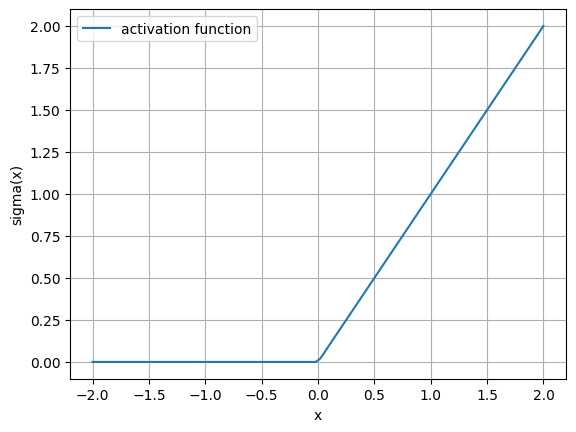

[ 3.98942280e-01  5.00000000e-01  3.98942280e-01  0.00000000e+00
 -3.98942280e-01  0.00000000e+00  1.19682684e+00 -3.06519084e-15
 -5.98413421e+00 -4.62916347e-14  4.18889394e+01 -4.68958206e-12
 -3.77000455e+02 -3.70619091e-10  4.14700500e+03 -2.71079443e-08]


In [75]:
# Choose the activation function among the activations below
# The cell computes the first num_coeff Hermite coefficients and defines the function g()

activation = 'ReLU' # 'ReLU', 'Tanh', 'Softplus', 'Erf', 'Arctan', 'LeakyReLU', 'ELU', 'Sigmoid', 'Quadratic', 'Cubic', 'Quadratic + Cubic', 'Linear + Quadratic + Cubic', 'Quadratic + Quartic'
num_coeff = 15

if (activation == 'ReLU'):
  analytic = True
else:
  analytic = False


if (analytic == True):
 if (activation == 'ReLU'):

      def sigma(x):
        return np.heaviside(x,1)*x

      def g(x):
        return -1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)

      def g_prime(x):
        return (np.arctan(x/np.sqrt(1-x**2))-x)/(2*np.pi)

      coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

else:

  if (activation == 'Tanh'):
    def sigma(x):
        return np.tanh(2*x)

  elif (activation == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma(x):
        return np.tanh(2*x)/np.sqrt(var)       

  elif (activation == 'ReLU numeric'):
    def sigma(x):
        return np.heaviside(x,1)*x

  elif (activation == 'Softplus'):
    def sigma(x):
        return np.log(1+np.exp(x))  

  elif (activation == 'Erf'):
    def sigma(x):
        return 0.5*(1 + special.erf(x/np.sqrt(2)))

  elif (activation == 'Arctan'):
    def sigma(x):
        return np.arctan(x)

  elif (activation == 'LeakyReLU'):
    def sigma(x):
        return np.heaviside(x,1)*x + 0.3*np.heaviside(-x,-1)*x

  elif (activation == 'ELU'):
    def sigma(x):
        return np.heaviside(x,1)*x + np.heaviside(-x,1)*(np.exp(x) - 1)

  elif (activation == 'Sigmoid'):
    def sigma(x):
        return 1/(1+np.exp(-x))

  elif (activation == 'Quadratic'):
    def sigma(x):
        return np.power(x,2)/np.sqrt(2)

  elif (activation == 'Cubic'):
    def sigma(x):
        return (x**3 - 3*x)/np.sqrt(6)

  elif (activation == 'Quadratic + Cubic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**3 - 3*x)/6

  elif (activation == 'Linear + Quadratic + Cubic'):
    def sigma(x):
        return x + (x**2 - 1)/np.sqrt(2) + (x**3 - 3*x)/6

  elif (activation == 'Quadratic + Quartic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**4 - 6*x**2 + 3)/8

  coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

  # Create the approximation function using the computed coefficients
  def g(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**i / math.factorial(i)
    return g

  def g_prime(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

# Plot the original function
x = np.linspace(-2, 2, 100)
plt.plot(x, sigma(x), label='activation function')

plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()
plt.grid(True)
plt.show()

print(coefficients)

In [76]:
# This cell computes the mmse and the overlaps for different alpha values.
# The distribution P_v is arbitrary and chosen at the beginning (Delta as well).

num_v = 600  # Number of states
mult_sigma = 4.0  # Number of sigmas to consider
v = [1] 
P_v = [1]
#v, P_v = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
v = np.array(v_ones)
P_v = np.array(P_v_ones)
q_W_init_info = 0.99*np.ones(v.shape[0]) # initial guess for q_W (informative)
q_W_init_unfo = 0.01*np.ones(v.shape[0]) # initial guess for q_W (uniformative)


# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha

Delta = 0.03

if (readouts == 'Read_ones'):
  rho_2 = 1+Gamma
else:
  rho_2 = 1 

# Range of alpha
Alpha_min = 0.01
Alpha_max = 10.0

init = Alpha_min
end = Alpha_max
num = 201

MMSE_NSB = []
q_W_NSB = []
q_2_NSB = []

MMSE_univ = []
q_W_univ = []
q_2_univ = []

for Alpha in np.linspace(init, end, num=num):
  if (Alpha == 0):
    Alpha = 0.01
  print('----------------------------------------------------------------')
  print("alpha =",Alpha)

  MMSE_new,q_W_new_gauss,q_2_new=mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_info,v,P_v,g,g_prime,coefficients,Alpha,Gamma,Delta,rho_2)
  MMSE_NSB.append(MMSE_new)
  q_W_NSB.append(q_W_new_gauss)
  q_2_NSB.append(q_2_new)
  print('MMSE NSB =',MMSE_new)
  MMSE_new,q_W_new_gauss,q_2_new=mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_info,v,P_v,g,g_prime,coefficients,Alpha,Gamma,Delta,rho_2, univ=True)
  MMSE_univ.append(MMSE_new)
  q_W_univ.append(q_W_new_gauss)
  q_2_univ.append(q_2_new)
  print('MMSE univ =',MMSE_new)

----------------------------------------------------------------
alpha = 0.01
MMSE NSB = 0.08977277895723812
MMSE univ = 0.08977451831115557
----------------------------------------------------------------
alpha = 0.05995


MMSE NSB = 0.08379139337079744
MMSE univ = 0.08379367321482206
----------------------------------------------------------------
alpha = 0.1099
MMSE NSB = 0.07711714704386224
MMSE univ = 0.07711978417459608
----------------------------------------------------------------
alpha = 0.15985000000000002
MMSE NSB = 0.07039015755353084
MMSE univ = 0.07039451671102642
----------------------------------------------------------------
alpha = 0.20980000000000001
MMSE NSB = 0.06410176431132436
MMSE univ = 0.06410824076261784
----------------------------------------------------------------
alpha = 0.25975
MMSE NSB = 0.05848346003653221
MMSE univ = 0.05849532465647145
----------------------------------------------------------------
alpha = 0.30970000000000003


C:\Users\rudys\AppData\Local\Temp\ipykernel_33960\164633772.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  return -1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)


MMSE NSB = 0.0535834607284113
MMSE univ = 0.05361084240491415
----------------------------------------------------------------
alpha = 0.35965
MMSE NSB = 0.049299791177510766
MMSE univ = 0.04941365744521137
----------------------------------------------------------------
alpha = 0.4096
MMSE NSB = 0.04551329330413917
MMSE univ = 0.04582442082863658
----------------------------------------------------------------
alpha = 0.45955
MMSE NSB = 0.04228449462021455
MMSE univ = 0.04275420287558568
----------------------------------------------------------------
alpha = 0.5095
MMSE NSB = 0.03955675108983098
MMSE univ = 0.04011957530394694
----------------------------------------------------------------
alpha = 0.55945
MMSE NSB = 0.03723947418090645
MMSE univ = 0.037847733311545395
----------------------------------------------------------------
alpha = 0.6094
MMSE NSB = 0.03525435244379782
MMSE univ = 0.03587749535554141
----------------------------------------------------------------
alpha = 0.

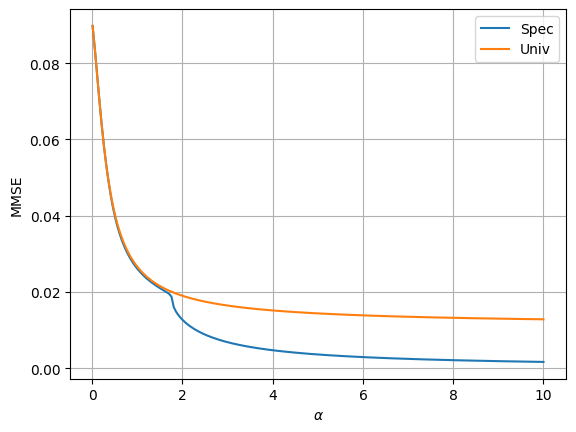

In [77]:
plt.plot(np.linspace(init, end, num=num),MMSE_NSB, label='Spec')
plt.plot(np.linspace(init, end, num=num),MMSE_univ, label='Univ')


#plt.title('MMSE with '+activation+' activation and delta ='+str(Delta)+' and gamma = '+str(Gamma))
plt.xlabel(r'$\alpha$')
plt.ylabel('MMSE')
plt.legend()
plt.grid(True)

plt.show()